In [20]:
import time
from pathlib import Path

CODE = Path.cwd()
ROOT = CODE.parent
DATA = ROOT / 'data'               

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mg_model import modular_MG_model as mod
from specifications import SPEC
from architechture import AC_Arch, DC_Arch
from mg_model import plot_functions as pf

In [ ]:
# Load Data 
spot_df = pd.read_csv(DATA / 'spot_df.csv', parse_dates = ['HourUTC'])
price_15min = spot_df.set_index('HourUTC')['SpotPriceEUR'].resample('15min').ffill()

pv_raw = pd.read_csv(DATA / 'pv_raw.csv', index_col = 'time', parse_dates = ['time'])
pv_15min = (pv_raw['P'] / 1e6).resample('15min').interpolate('linear')

# Day-ahead scheduling test one day
daily_load  = np.full(SPEC.N_T, SPEC.LOAD_MW) 

Run for 20 Random days

In [22]:
rng = np.random.default_rng(0)
all_days = pd.date_range('2025-01-02', '2025-09-29', freq = 'D')
days = pd.DatetimeIndex(rng.choice(all_days, size = 20, replace = False)).sort_values().strftime('%Y-%m-%d')

In [23]:
days = pd.DatetimeIndex([
    '2025-01-28', '2025-02-11', '2025-02-19', '2025-03-05',
    '2025-03-12', '2025-03-14', '2025-03-24', '2025-03-25',
    '2025-03-28', '2025-04-13', '2025-04-14', '2025-05-04',
    '2025-05-05', '2025-06-06', '2025-06-21', '2025-07-28',
    '2025-08-13', '2025-08-15', '2025-08-27', '2025-09-15'
]).sort_values().strftime('%Y-%m-%d')


summary
model       date  status   cost_eur  efficiency_pct  n_stages  total_loss_MWh  demand_supply_MWh  grid_import_MWh  DER_generation_MWh  bess_cycles
   AC 2025-01-28 optimal 8,271.9774         93.5155         9          9.4746            84.7200          90.3610              0.2337       2.0529
   AC 2025-02-11 optimal 6,026.9210         93.6773         9          9.3182            84.7200          87.3894              3.0488       1.8884
   AC 2025-02-19 optimal 8,747.6765         94.0907         9          8.9208            84.7200          87.6137              2.4271       1.5142
   AC 2025-03-05 optimal 1,106.6300         93.1740         9          9.8066            84.7200          88.7641              2.1626       2.1603
   AC 2025-03-12 optimal 9,565.9956         93.9628         9          9.0434            84.7200          83.2902              6.8732       1.5143
   AC 2025-03-14 optimal 9,260.1529         93.8764         9          9.1263            84.7200          81.

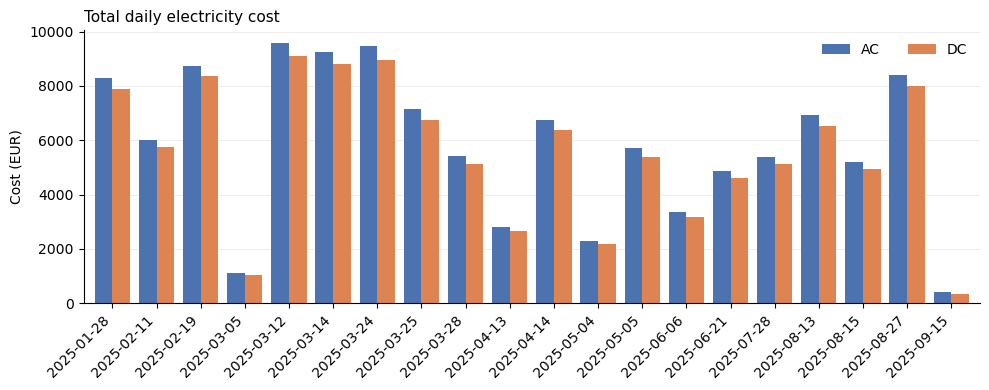

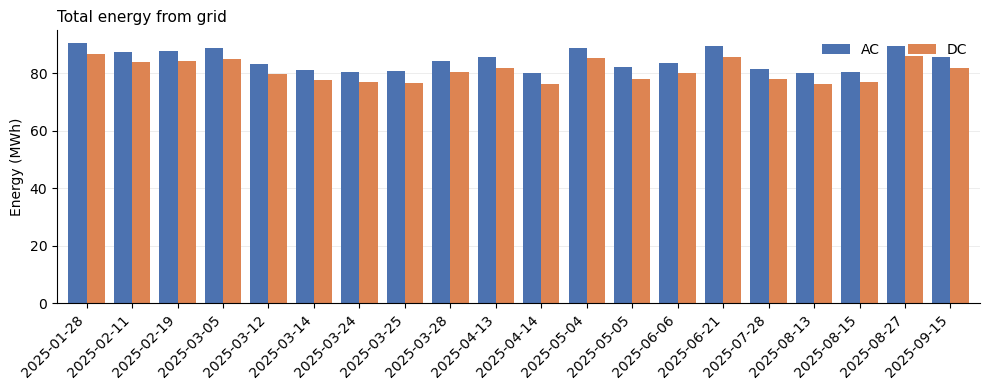

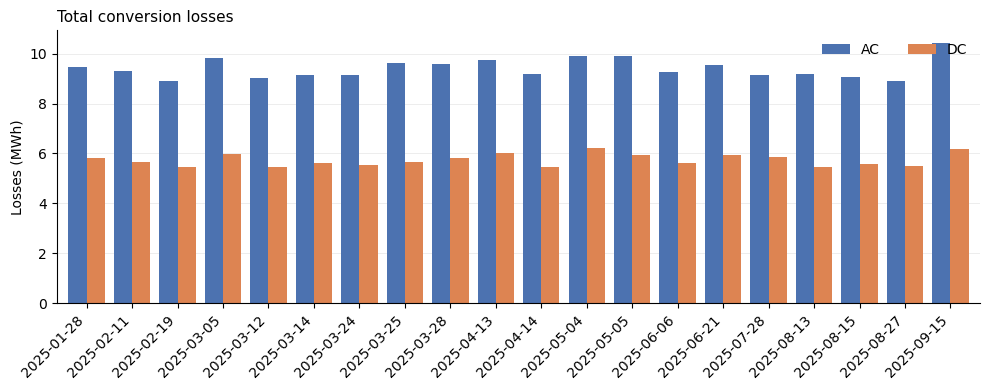

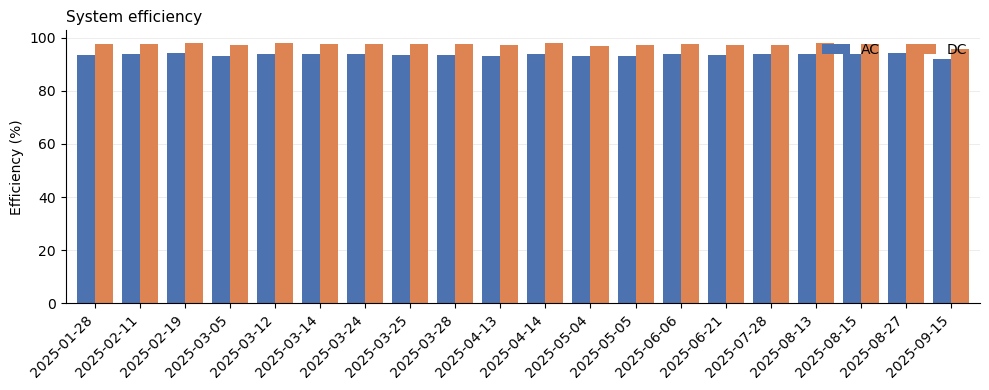

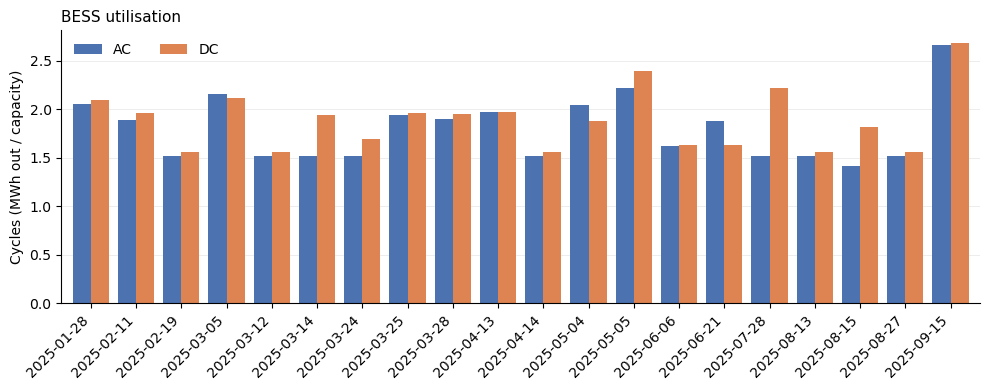

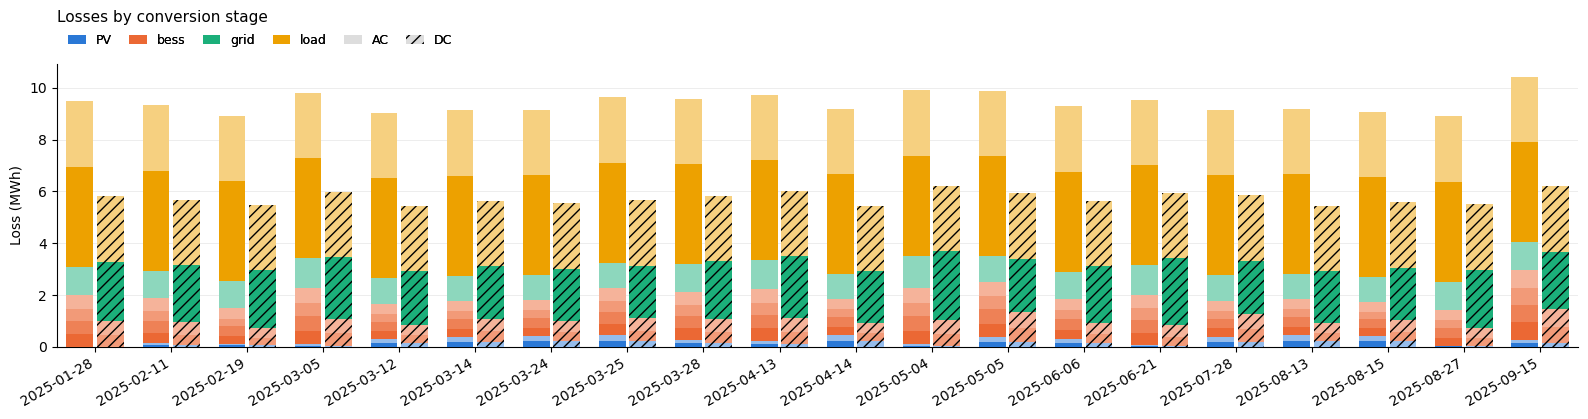

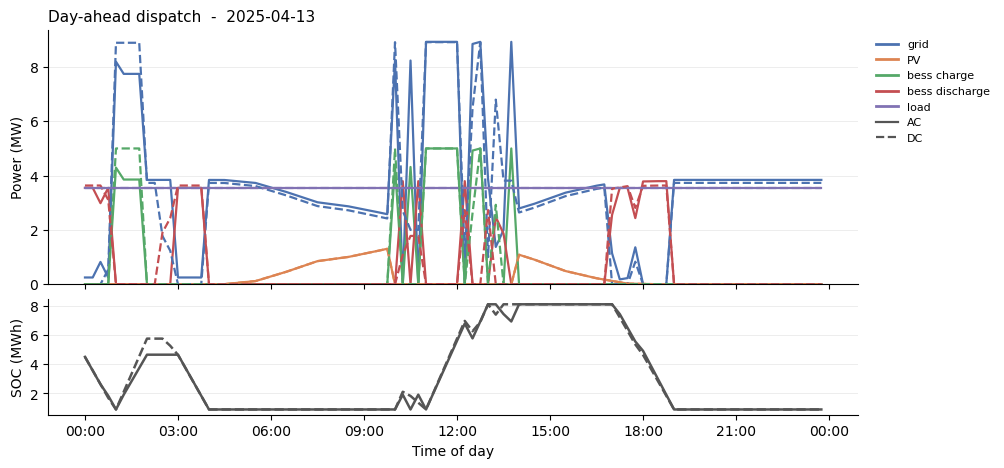

In [ ]:
results = []
for arch, name in [(AC_Arch, 'AC'), (DC_Arch, 'DC')]:
    for d in days:
        sc = mod.Scenario(n_t = SPEC.N_T, dt = SPEC.DT, date = d,
                          data = {'grid': {'price': price_15min[d].values}, 'PV': {'production': pv_15min[d].values}, 'bess': {'soc_init': 0.5}, 'load': {'demand': daily_load}})
        results.append(mod.build_and_solve(arch, sc, name = name, verbose = False))

print('\nsummary'); pf.summary_table(results, show = True)
print('\nlosses by stage [MWh]'); pf.loss_table(results, show = True)
print('\nstage share of own total [%]'); pf.stage_share_table(results, show = True)

for f in (pf.plot_cost, pf.plot_grid_import, pf.plot_losses, pf.plot_efficiency, pf.plot_bess_utilization, pf.plot_loss_breakdown):
    f(results)

d = days[9]
pf.plot_dispatch([r for r in results if r['date'] == d], index = price_15min[d].index)
plt.show()
